# 12 · Random Forest + Kriging

Template para `RegressionKrigingModel`, separando claramente la parte no lineal del bosque y el ajuste espacial sobre residuos.

## Hipótesis del modelo

- El Random Forest captura relaciones no lineales y umbrales.
- El kriging sobre residuos agrega estructura espacial que el bosque no explica por sí solo.
- La interpretación puede combinar importancia global de features con mapas de residuo antes y después del kriging.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import geopandas as gpd
import seaborn as sns


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.rfrkModel import RegressionKrigingModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import *

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "12_rf_kriging"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Datos y configuración

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)



target_col = "log_precio"   
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral'
]

feature_cols_to_std = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
]


In [3]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

## Entrenamiento

In [4]:
rf_params = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 3,
    "max_features": "log2",
}

kriging_params = {
    "n_closest_points": 7,
    "variogram_model": "linear",
    "pseudo_inv": True,
    "pseudo_inv_type": "pinvh",
}

model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params)
model.fit(X_train, y_train, coords_train)
model


Finished learning regression model
Finished kriging residuals


## Tuning tentativo

Acá podés barrer hiperparámetros del bosque y del kriging, o hacer primero tuning del RF y después del componente espacial.

In [5]:

model.tune_hyperparameters(X_test, y_test.values.ravel(), coords_test)
best_config = {"RegressionKriging_params": rf_params, "kriging_params": kriging_params, "selected_k": getattr(model, "kriging_params_", {}).get("n_closest_points", None)}
best_config


Finished learning regression model
Finished kriging residuals
Finished learning regression model
Finished kriging residuals
Finished learning regression model
Finished kriging residuals
Finished learning regression model
Finished kriging residuals


{'RegressionKriging_params': {'n_estimators': 200,
  'max_depth': 15,
  'min_samples_leaf': 1,
  'max_features': 'sqrt'},
 'kriging_params': {'n_closest_points': 5,
  'variogram_model': 'linear',
  'pseudo_inv': True,
  'pseudo_inv_type': 'pinvh'},
 'selected_k': None}

## Evaluación global

In [12]:
y_pred_log = model.predict(
    X_val,
    coords_val
)

# revertir log
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_val)

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics

{'rmse': 53796.86549152518,
 'mae': 32092.389460646027,
 'r2': 0.7409863528964387,
 'bias': 3881.4559667817766,
 'median_abs_error': 18486.328008209446,
 'mape': 20.688209252560572}

## Visualización


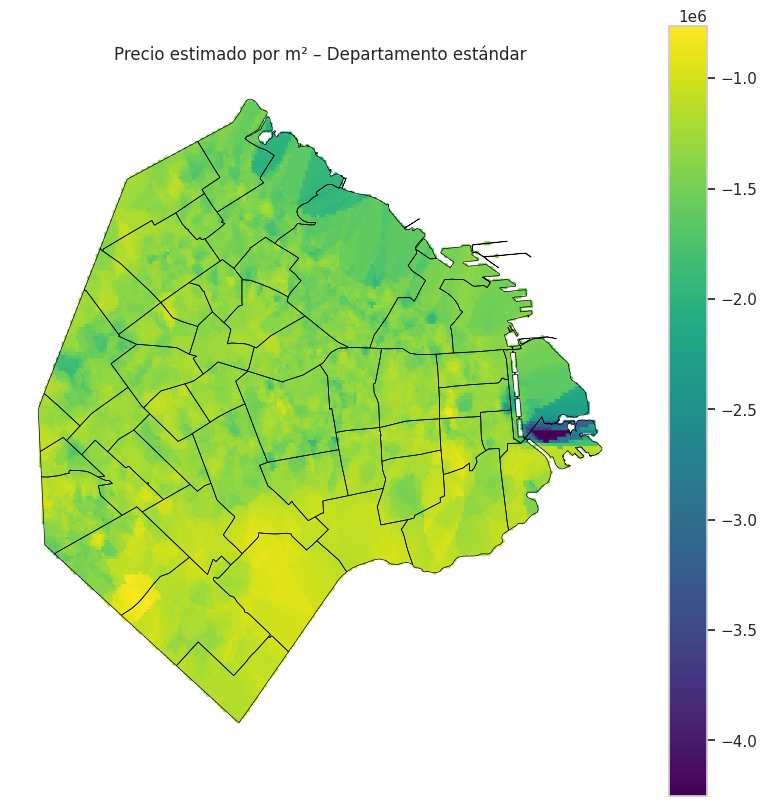

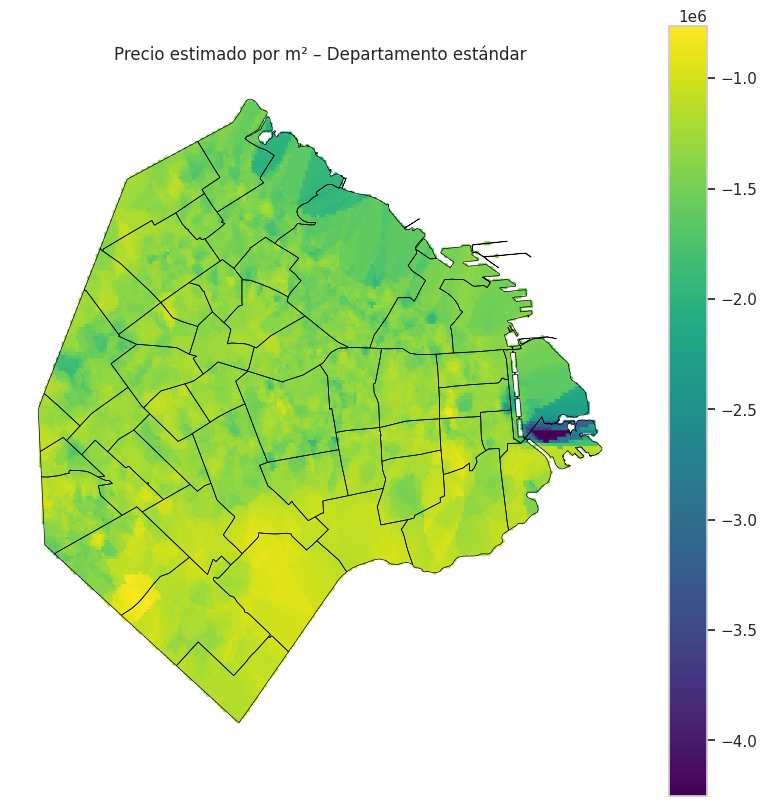

In [7]:
barrios_path = PROJECT_ROOT / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

#mapa.save("mapa_modelo_lgwr.png")

#mapa.save("mapa_modelo_lgwr.pdf")



## Interpretación del Random Forest

In [8]:
# feature_importance = pd.DataFrame({
#     "feature": feature_cols,
#     "importance": model.feature_importances_(),
# }).sort_values("importance", ascending=False)
# feature_importance

## Residuo del bosque vs residuo final

Si querés entender el aporte del kriging, compará explícitamente el error del RF puro contra el error final del modelo combinado.

In [9]:
# rf_only_pred = model.rf_.predict(X_test)
# comparison = pd.DataFrame({
#     "y_true": y_test,
#     "rf_pred": np.asarray(rf_only_pred).reshape(-1),
#     "rk_pred": np.asarray(y_pred).reshape(-1),
# })
# comparison["rf_residual"] = comparison["y_true"] - comparison["rf_pred"]
# comparison["rk_residual"] = comparison["y_true"] - comparison["rk_pred"]
# comparison.head()

## Export

In [10]:
# test_export = test_df[[target_col] + coord_cols].copy()
# test_export = test_export.rename(columns={target_col: "y_true"})
# test_export["y_pred"] = np.asarray(y_pred).reshape(-1)
# test_export["residual"] = test_export["y_true"] - test_export["y_pred"]
# test_export["rf_only_pred"] = np.asarray(rf_only_pred).reshape(-1)
# test_export["split"] = "test"
# test_export.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=False)
# feature_importance.to_parquet(OUTPUT_DIR / "interpretability.parquet", index=False)
# run_config = {"rf_params": rf_params, "kriging_params": kriging_params}
# (OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False))
# (OUTPUT_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2, ensure_ascii=False))